In [1]:
import numpy as np
import matplotlib.pyplot as plt

from load_data import load_full_volume
from scipy.ndimage import gaussian_filter


In [2]:
image_input = '/run/media/anokhver/Data/Veronika/ctu/Microscopy/Microscopy/20251030/2_5_BAEO_1_Multichannel Z-Stack_20251030_96.vsi'
data = load_full_volume(image_input)


SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See https://www.slf4j.org/codes.html#noProviders for further details.


Physical pixel sizes: PhysicalPixelSizes(Z=None, Y=0.10685428060522417, X=0.10685428060522417)
Dimensions: <Dimensions [T: 1, C: 3, Z: 37, Y: 2304, X: 2304]>
Shape: (1, 3, 37, 2304, 2304)
Loaded shape: (3, 37, 2304, 2304) (C, Z, Y, X)


### Batching and plotting

In [3]:
import math


def show_imgs(images, titles=None, cmap=None, figsize=None, max_cols=3):
    images = list(images)
    img_count = len(images)
    if img_count == 0:
        raise ValueError("images must contain at least one item")

    cols = min(max_cols, img_count)
    rows = math.ceil(img_count / cols)

    if figsize is None:
        figsize = (cols * 4, rows * 4)

    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)
    if not isinstance(axs, np.ndarray):
        axs = np.array([axs])
    axs = axs.ravel()

    for i in range(rows * cols):
        ax = axs[i]
        if i < img_count:
            img = np.asarray(images[i])
            ax.imshow(img, cmap=None if img.ndim == 3 and img.shape[-1] in (3, 4) else cmap)
            if titles is not None and i < len(titles):
                ax.set_title(titles[i])
        ax.axis('off')

    plt.tight_layout()
    return fig, axs[:img_count]

In [4]:
def extract_patches(data, patch_size=32):
    """
    Extract 32x32 patches from 2D image with channels.

    Args:
        data: Single 2D image with channels (C, H, W) or (C, Y, X)
        patch_size: Patch size (default 32)

    Returns:
        patches: (N, C, patch_size, patch_size)
    """
    C, H, W = data.shape

    n_h = H // patch_size
    n_w = W // patch_size

    # Crop to exact multiple
    data = data[:, :n_h * patch_size, :n_w * patch_size]

    # Reshape: (C, H, W) -> (C, n_h, patch_size, n_w, patch_size)
    patches = data.reshape(C, n_h, patch_size, n_w, patch_size)
    # Transpose: (n_h, n_w, C, patch_size, patch_size)
    patches = patches.transpose(1, 3, 0, 2, 4)
    # Flatten: (N, C, patch_size, patch_size)
    patches = patches.reshape(-1, C, patch_size, patch_size)

    return patches


In [5]:
data_z_sliced  = data[:, 37 // 2, :, :]
batch = extract_patches(data_z_sliced, patch_size=32)

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

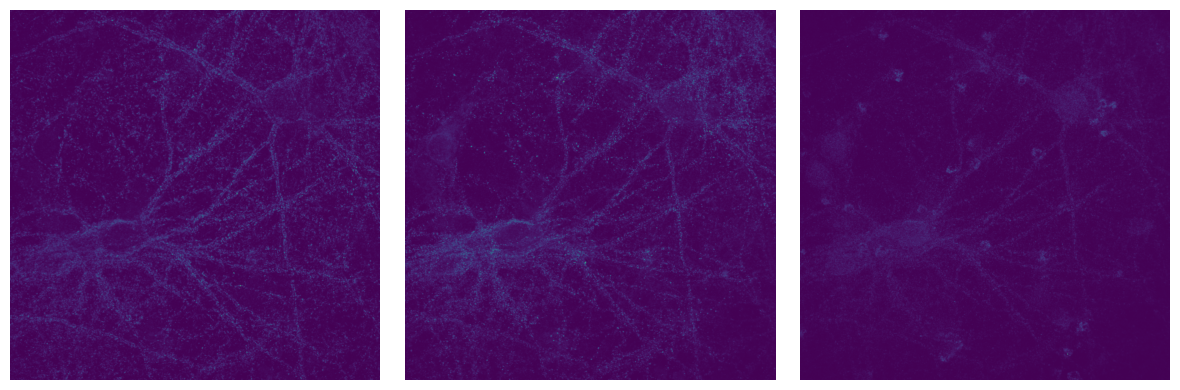

In [6]:
show_imgs(data_z_sliced)

### Hessian

In [7]:
def compute_hessian_2d(image, sigma):
    """
    Compute 2D Hessian matrix eigenvalues.

    For a 2D image, Hessian is:
    H = [[Ixx, Ixy],
         [Iyx, Iyy]]

    Returns:
        lambda1, lambda2: eigenvalues sorted by absolute value (|λ1| <= |λ2|)
    """
    # Smooth first (this is the "window" - Gaussian kernel with std=sigma)
    smoothed = gaussian_filter(image, sigma=sigma)
    # smoothed = image
    # Compute second derivatives
    Ixx = gaussian_filter(smoothed, sigma=sigma, order=[2, 0])
    Ixy = gaussian_filter(smoothed, sigma=sigma, order=[1, 1])
    Iyy = gaussian_filter(smoothed, sigma=sigma, order=[0, 2])

    # For each pixel, we have a 2x2 Hessian matrix
    # Compute eigenvalues analytically (faster than numpy.linalg.eigh)
    # For 2x2 symmetric matrix: λ = (trace ± sqrt(trace² - 4*det)) / 2
    trace = Ixx + Iyy
    det = Ixx * Iyy - Ixy * Ixy
    discriminant = np.sqrt(np.maximum(trace*trace - 4*det, 0))

    lambda1 = (trace - discriminant) / 2
    lambda2 = (trace + discriminant) / 2

    # Sort by absolute value
    lambda1, lambda2 = np.minimum(np.abs(lambda1), np.abs(lambda2)), \
                       np.maximum(np.abs(lambda1), np.abs(lambda2))

    return lambda1, lambda2

# Frangi 1

In [ ]:
def frangi_filter_2d(lambda1, lambda2, beta=0.5, c=15):
    """
    Frangi vesselness filter for 2D images.

    Parameters:
        beta:
        c:
    
    Multiscale vessel enhancement filtering (MICCAI 1998) 

    """
    # Avoid division by zero
    lambda2_safe = np.where(np.abs(lambda2) < 1e-10, 1e-10, lambda2)

    R_b = lambda1 / lambda2_safe
    S = np.sqrt(lambda1**2 + lambda2**2)

    response = np.zeros_like(lambda1)

    mask = lambda2 > 0

    response[mask]= np.exp(-R_b[mask]**2 / (2*beta**2)) * \
                   (1 - np.exp(-S[mask]**2 / (2*c**2)))

   
    return response

In [ ]:
def multiscale_frangi_2d(image, sigmas=[0.1, 0.3, 0.5, 0.7, 1], beta=0.5):
    """
    Multi-scale Frangi filtering.

    """
    responses = []

    for sigma in sigmas:
        print(f"Processing sigma={sigma}...")
        lambda1, lambda2 = compute_hessian_2d(image, sigma)

        # Adjust c parameter based on sigma (DDeep3M uses c=2e6, but scale it)
        c = 10 * sigma
        response = frangi_filter_2d(lambda1, lambda2, beta, c)
        responses.append(response)

    # Take maximum across scales
    multiscale_response = np.maximum.reduce(responses)

    return multiscale_response, responses

In [ ]:
def normalize_image(image):
    """Normalize to [0, 1] range"""
    return (image - image.min()) / (image.max() - image.min())

data_z_sliced_normalized = normalize_image(data_z_sliced)


In [ ]:
sigmas = [0.1, 0.2, 0.5]  # pixels
# enhanced_multiscale, scale_responses = multiscale_frangi_2d(img_normalized[2, :, :], sigmas)
enhanced_multiscale, scale_responses = multiscale_frangi_2d(data_z_sliced[1, :, :], sigmas)


In [ ]:
show_imgs(data_z_sliced)

In [ ]:
show_imgs(scale_responses)